Below is an example of training a simple neural network to fit the function $f(\mathbf{x})$,

$$
f(\mathbf{x}) = \sin(x) + 2\cos(x)
$$

In [293]:
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt

device = torch.device("cpu")
# add generator for consistency between runs
gen = torch.Generator(device=device).manual_seed(1)

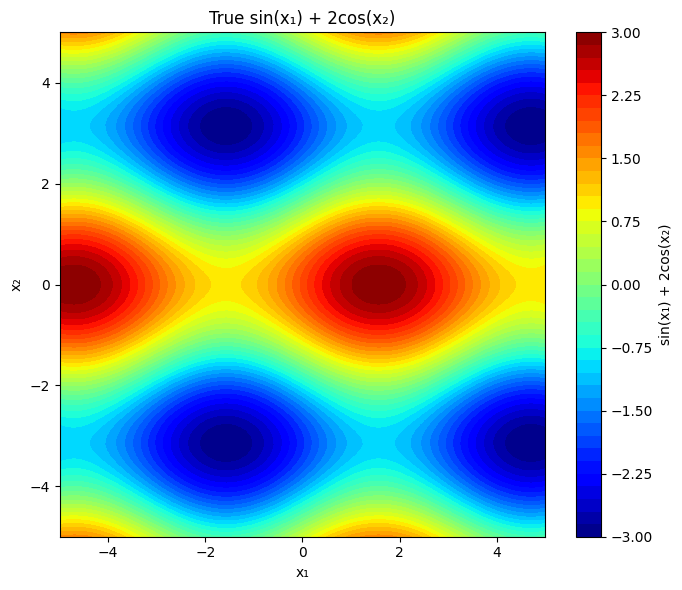

In [294]:
# True function
points_per_dim = 100

linx1 = torch.linspace(-5, 5, points_per_dim)
linx2 = torch.linspace(-5, 5, points_per_dim)
x1, x2 = torch.meshgrid(linx1, linx2, indexing='ij')

z = torch.sin(x1) + 2 * torch.cos(x2)

plt.figure(figsize=(7, 6))
plt.contourf(x1.numpy(), x2.numpy(), z.numpy(), levels=50, cmap='jet')
plt.colorbar(label='sin(x₁) + 2cos(x₂)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('True sin(x₁) + 2cos(x₂)')
plt.tight_layout()
plt.show()


In [295]:
# Layer 0 (input layer)
# N x D
# we are using row vectors
n_samples = 50
x_train = torch.rand(n_samples, 2, generator=gen) * 10 - 5  # uniform in [-5, 5]

In [296]:
# layer 1
layer1_weights = torch.randn((3, 2), requires_grad=True, generator=gen)
layer1_bias = torch.randn(3, requires_grad=True, generator=gen)
layer1_z = x_train @ layer1_weights.T + layer1_bias
layer1_a = F.tanh(layer1_z)
layer1_a.shape


torch.Size([50, 3])

In [297]:
# layer 2
layer2_weights = torch.randn((4, 3), requires_grad=True, generator=gen)
layer2_bias = torch.randn(4, requires_grad=True, generator=gen)
layer2_z = layer1_a @ layer2_weights.T + layer2_bias
layer2_a = F.tanh(layer2_z)
layer2_a.shape

torch.Size([50, 4])

In [298]:
# layer 3 (Output Layer)
layer3_weights = torch.randn((1, 4), requires_grad=True, generator=gen)
layer3_bias = torch.randn(1, requires_grad=True, generator=gen)
predicted = layer2_a @ layer3_weights.T + layer3_bias
predicted.shape

torch.Size([50, 1])

In [299]:
# Loss function
y_train = torch.sin(x_train[:, 0]) + 2 * torch.cos(x_train[:, 1])  # shape (n_samples,)
y_train = y_train.unsqueeze(1) # shape (n_samples, 1)

loss = torch.sum((predicted - y_train)**2) / n_samples

loss

tensor(2.6133, grad_fn=<DivBackward0>)

In [300]:
# gradient check against torch

delta_output_layer = (2 / n_samples) * (predicted - y_train)
grad_W3 = delta_output_layer.T @ layer2_a
grad_b3 = torch.sum(delta_output_layer, dim=0)
delta_a2 = (delta_output_layer @ layer3_weights) * (1-torch.tanh(layer2_z)**2)
grad_W2 = delta_a2.T @ layer1_a
grad_b2 = torch.sum(delta_a2, dim=0)
delta_a1 = (delta_a2 @ layer2_weights) * (1-torch.tanh(layer1_z)**2)
grad_W1 = delta_a1.T @ x_train
grad_b1 = torch.sum(delta_a1, dim=0)

In [301]:
print("Manual backpropagation")
print("Layer 3")
print(grad_W3)
print(grad_b3)

print("Layer 2")
print(grad_W2)
print(grad_b2)

print("Layer 1")
print(grad_W1)
print(grad_b1)

Manual backpropagation
Layer 3
tensor([[ 0.0134,  0.0287, -1.1367,  0.7480]], grad_fn=<MmBackward0>)
tensor([-0.9905], grad_fn=<SumBackward1>)
Layer 2
tensor([[-0.0682,  0.0347, -0.0449],
        [ 0.0631, -0.0210,  0.1884],
        [ 0.0315,  0.0144,  0.0219],
        [-0.1138, -0.2889,  0.1217]], grad_fn=<MmBackward0>)
tensor([0.0526, 0.3921, 0.0245, 0.3915], grad_fn=<SumBackward1>)
Layer 1
tensor([[-0.2154, -0.0504],
        [ 0.0122,  0.1566],
        [ 0.2698,  0.0044]], grad_fn=<MmBackward0>)
tensor([-0.0394,  0.0694,  0.1099], grad_fn=<SumBackward1>)


In [302]:
# torch gradients
loss.backward()

In [303]:
print("Torch backpropagation")
print("Layer 3")
print(layer3_weights.grad)
print(layer3_bias.grad)

print("Layer 2")
print(layer2_weights.grad)
print(layer2_bias.grad)

print("Layer 1")
print(layer1_weights.grad)
print(layer1_bias.grad)

Torch backpropagation
Layer 3
tensor([[ 0.0134,  0.0287, -1.1367,  0.7480]])
tensor([-0.9905])
Layer 2
tensor([[-0.0682,  0.0347, -0.0449],
        [ 0.0631, -0.0210,  0.1884],
        [ 0.0315,  0.0144,  0.0219],
        [-0.1138, -0.2889,  0.1217]])
tensor([0.0526, 0.3921, 0.0245, 0.3915])
Layer 1
tensor([[-0.2154, -0.0504],
        [ 0.0122,  0.1566],
        [ 0.2698,  0.0044]])
tensor([-0.0394,  0.0694,  0.1099])


In [304]:
# training loop

LR = 0.1

# we are not using torch's backward
# so do not evaluate gradient here

with torch.no_grad():
    for i in range(10000):

        delta_output_layer = (2 / n_samples) * (predicted - y_train)
        grad_W3 = delta_output_layer.T @ layer2_a
        grad_b3 = torch.sum(delta_output_layer, dim=0)
        delta_a2 = (delta_output_layer @ layer3_weights) * (1-torch.tanh(layer2_z)**2)
        grad_W2 = delta_a2.T @ layer1_a
        grad_b2 = torch.sum(delta_a2, dim=0)
        delta_a1 = (delta_a2 @ layer2_weights) * (1-torch.tanh(layer1_z)**2)
        grad_W1 = delta_a1.T @ x_train
        grad_b1 = torch.sum(delta_a1, dim=0)

        # go against gradient of parameters because we want to minimize loss
        layer3_weights -= LR * grad_W3
        layer3_bias -= LR * grad_b3

        layer2_weights -= LR * grad_W2
        layer2_bias -= LR * grad_b2

        layer1_weights -= LR * grad_W1
        layer1_bias -= LR * grad_b1

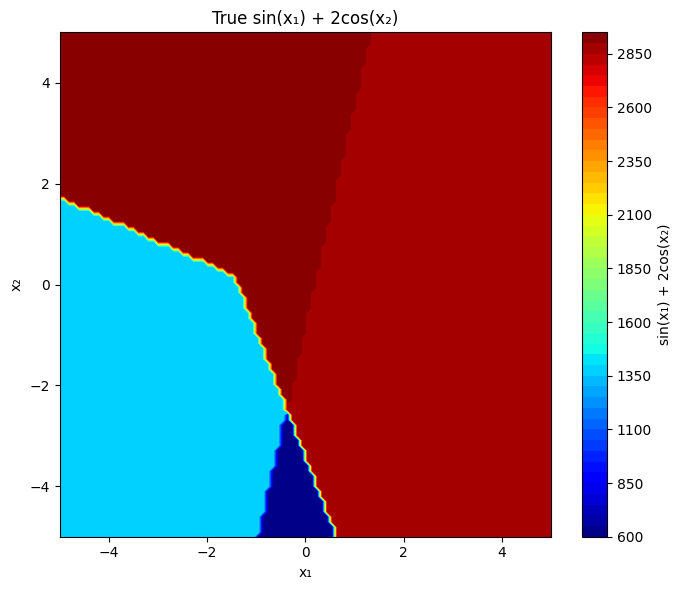

In [305]:

grid_input = torch.stack([x1.flatten(), x2.flatten()], dim=1)

with torch.no_grad():
    layer1_z = grid_input @ layer1_weights.T + layer1_bias
    layer1_a = F.tanh(layer1_z)

    layer2_z = layer1_a @ layer2_weights.T + layer2_bias
    layer2_a = F.tanh(layer2_z)

    predicted = layer2_a @ layer3_weights.T + layer3_bias

    predicted = predicted.reshape(points_per_dim, points_per_dim)

plt.figure(figsize=(7, 6))
plt.contourf(x1.numpy(), x2.numpy(), predicted.numpy(), levels=50, cmap='jet')
plt.colorbar(label='sin(x₁) + 2cos(x₂)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('True sin(x₁) + 2cos(x₂)')
plt.tight_layout()
plt.show()
